### Метод опорных векторов

#### Цель работы

Изучить работу метода опорных векторов для решения задач классификации и регрессии, познакомиться с основными особенностями и вариациями данного метода. Изучить соответствующие классы библиотеки sklearn, их параметры и атрибуты, применимые на практике.

#### Содержание работы

1. Сгенерируйте линейно разделимый датасет для классификации из двух признаков. Постройте на нем опорно-векторный классификатор без ядра с параметром С=100. Изобразите границу принятия решения и линию зазора на графике.
1. Сгенерируйте линейно неразделимый датасет с зазором между классами. Повторите виуальный анализ на нем.
1. Сгенерируйте неразделимый датасет так, чтобы классы пересекались. Повторите построение и оценку метода опорных векторов на нем.

#### Методические указания

Метод опорных векторов SVM (Support Vector Machines) — это алгоритм машинного обучения, используемый для решения задач классификации, регрессии и обнаружения выбросов. 

Рассмотрим подробно SVM для метода бинарной классификации (разделеня на два класса) в случае линейно разделимых и линейно неразделимых классов.

**Случай линейно разделимых классов** (т.е. таких, для которых возможно построить гиперплоскость в n-мерном пространстве для разделения объектов двух классов):
Модель SVM ищет гиперплоскость с максимальной шириной разделяющей полосы (margin), называемой линией зазора, то есть разделяющую гиперплоскость, максимально отдаленную от обоих классов.

Чтобы иметь возможность наглядной визуализации рассмотрим задачу на примере данных с двумя признаками. На рисунке ниже изображены различные варианты проведения разделяющей гиперплоскости (в данном случае прямой) с линией зазора.

![Разные зазоры](https://github.com/koroteevmv/ML_course/blob/main/ML3.2%20svm/img/ml32-1.jpeg?raw=true)

Классификатор SVM устанавливает самую широкую, какую только возможно, полосу (представленную параллельными
пунктирными линиями на рисунке ниже) между классами.

![Максимальный зазор](https://github.com/koroteevmv/ML_course/blob/main/ML3.2%20svm/img/ml32-2.jpeg?raw=true)

Уравнения гиперплоскости и линий зазора имеют вид соответственно


$<\vec{w} ;\vec{x} > + b = 0$

$<\vec{w} ;\vec{x} > + b = 1$

$<\vec{w} ;\vec{x} > + b = -1$

Оптимальные значения $\vec{w}$ и $b$ подбираются в результате решения задачи оптимизации, которая заключается в минимизации функции потерь и максимизации зазора между классами.

Метод опорных векторов, решает задачу оптимизации, подбирая прямую с максимальным зазором между ближайшими точками разных классов. Эти точки называются опорными векторами.

В библиотеке `Scikit-Learn` метод опорных векторов для классификации реализован в `sklearn.svm.SVC`. 
Для линейно разделимых данных можно использовать класс SVC с линейным ядром (`kenel = 'linear'`). Также в `Scikit-Learn` есть другая реализация метода опорных векторов для случая линейной разделимости данных `sklearn.svm.LinearSVC`, но в нём нет возможности выводить информацию об опорных векторах.

Классификация методом опорных векторов может осуществляться с *жёстким зазором* (hard margin classification) и с *мягким зазором* (soft margin classification). Разберёмcя, что это значит.

При классификации с *жестким зазором* все образцы должны находятся вне линии зазора. 

При классификацией с мягким зазором допускаются нарушения границы зазора, т.е. появления экземпляров, которые оказываются внутри полосы зазора или даже на неправильной стороне, отыскивается баланс между удержанием полосы как можно более широкой и ограничением количества нарушений зазора.

Классификация с жестким зазором  имеет недостатки. Во-первых, она работает, только если данные являются линейно разделимыми. Во-вторых, она довольно чувствительна к выбросам. Чтобы избежать таких проблем, предпочтительнее применять более гибкую модель. 

В классах `SVM` библиотеки `Scikit-Learn` можно управлять упомянутым балансом, используя гиперпараметр `C`: меньшее значение `C` ведет к более широкой полосе, но большему числу нарушений зазора, а чем больше `C`, тем более жёсткий зазор.

**Случай линейно неразделимых классов**:

В случае линейной неразделимости вводятся дополнительные переменные, характеризующие допустимую ошибку классификации на различных объектах, и применяется трюк, заключающийся в переходе от скалярного произведения к нелинейной функции ядра (kernel trick). Данный прием позволяет перейти в пространство большей размерности, где выборка может быть линейно разделена.

Рассмотрим три вида ядер:

1. *Линейное ядро* (kernel = 'linear' ) — это ядро, которое строит гиперплоскость для разделения данных. Оно часто используется в задачах с линейно разделимыми данными. В математическом смысле линейное ядро вычисляет скалярное произведение между векторами признаков объектов. Если объекты невозможно разделить линейной гиперплоскостью, то следует с этим ядром использовать классификацию с мягким зазором (soft margin), которая позволяет допустить ошибки классификации и при этом сохранить разделяющую гиперплоскость.

2. *Радиальное базисное ядро* (kernel = 'rbf') — это наиболее часто используемое ядро (установлено по умолчанию), которое может разделять данные, не являющиеся линейно разделимыми. Оно создает границу принятия решений в виде радиально-симметричного колокола.

3. *Ядро с полиномиальной функцией* (kernel = 'poly') — это ядро, которое вводит полиномиальную функцию в пространство признаков для разделения данных. Это может быть полезно для данных, которые не могут быть разделены гиперплоскостью.

Существуют и другие ядра, но они применяются гораздо реже.

Посмотрим, как работает данный метод на практике.

##### Линейно разделимые данные

Для самого простого случая сгенерируем линейноразделимый датасет. Для этого воспользуемся средствами библиотеки sklearn:

In [128]:
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

Изобразим получившийся датасет на графике:

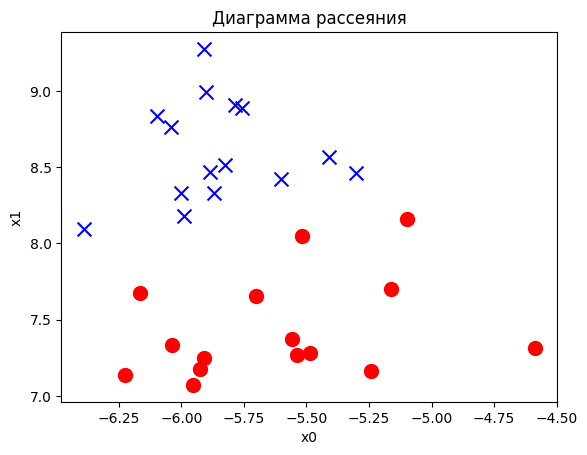

In [129]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

Вы можете использовать другие параметры при генерации. Главное убедиться, что получившийся датасет линейно разделим и меет зазор между классами. 

Теперь создадим и обучим модель классификации на основе метода опорных векторов (опорно-векторный классификатор). Обратите внимание, что мы используем высокое значение С для задания жесткого зазора между классами. Также мы должны явно указать вид используемой ядерной функции. Нам сейчас нужен классификатор с линейным ядром (без ядра):

In [130]:
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.svm import SVC 

svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Уже знакомые нам поля класса (которые присутствуют и в объектах классов линейных моделей) выводят коэффициенты линейной функции, используемой как граница принятия решения:

In [131]:
svm_linear.coef_

array([[-2.49920793,  6.14683189]])

И также как в других моделях, свободный коэффициет указывается отдельно:

In [132]:
svm_linear.intercept_

array([-64.2533988])

Эту информацию можно использовать для построения границы принятия решений. Изобразим границу принятия решения на графике:

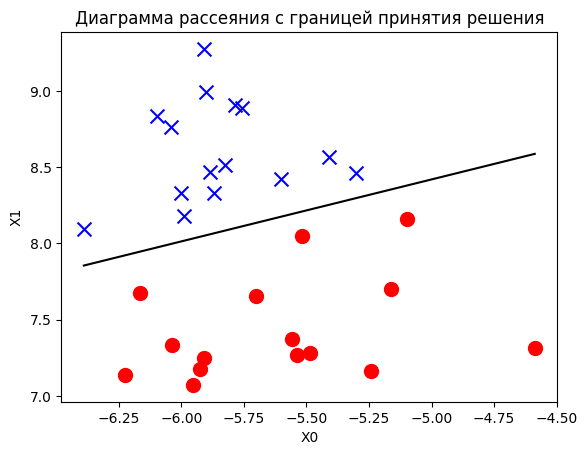

In [133]:
import numpy as np
X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])

plt.plot(X0,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c границей принятия решения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

Мы должны получить линейную границу

Объект метода опорных векторов в sklearn содержит ряд специфических полей и методов, с помощью которых можно посмотреть информацию о том, какие именно вектора (точки исходной выборки) стали опорными. В частности, так можно вывести самии координаты опорных векторов:

In [134]:
svm_linear.support_vectors_

array([[-5.51629264,  8.04763857],
       [-5.30025769,  8.46071981],
       [-5.9879581 ,  8.18112559]])

А так - посмотреть индексы опорных векторов в исходном наборе данных:

In [135]:
svm_linear.support_

array([ 0,  8, 29], dtype=int32)


Иногда бывает полезно узнать количество опорных векторов. Особенно в задачах множественной классификации, когда опорные вектора соответствуют разным классам. Для этого существует также специальное поле:

In [136]:
svm_linear.n_support_

array([1, 2], dtype=int32)

Используя эти данные можно визуализировать сами опорные вектора:

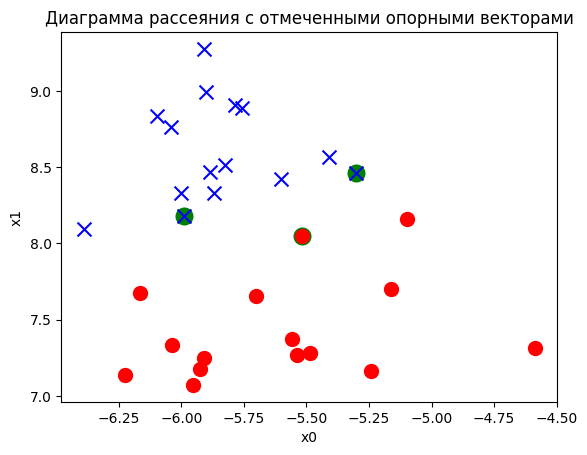

In [137]:
plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c отмеченными опорными векторами")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

Мы видим на графике, какие точки метод счел опорными

Если отступить отграницы принятия решений расстояние, соответствующее росту функции на единицу в обе стороны мы получим границы области зазора. Давайте построим эту границу:

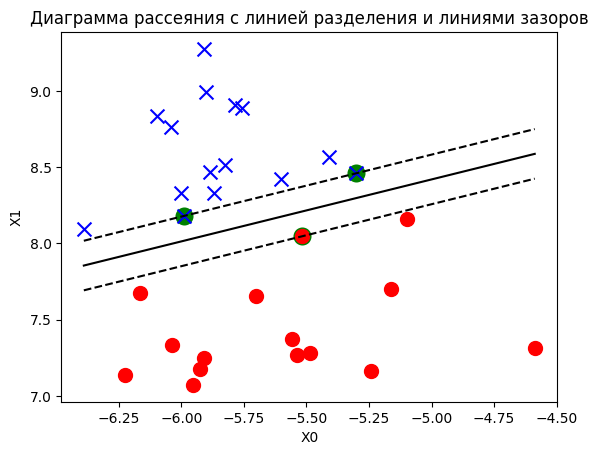

In [138]:
plt.plot(X0,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')

plt.plot(X0,(-svm_linear.intercept_[0]-1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0,linestyle='--', c='k')
plt.plot(X0,(-svm_linear.intercept_[0]+1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0,linestyle='--', c='k')

plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения и линиями зазоров")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

Мы видим, что граница принятия решения располагается ровно посередине зазора, а границы зазора проходят ровно через опорные вектора:

Но более правильно троить границу принятия решения как линии уровня на поверхности фукнции гипотезы:

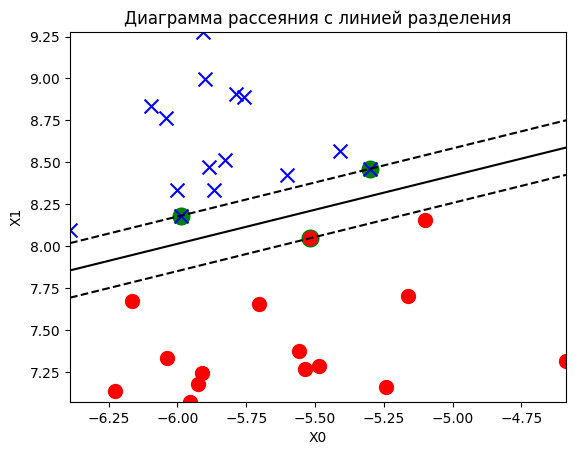

In [139]:
X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), X.shape[0])
X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), X.shape[0])

X0_grid, X1_grid = np.meshgrid(X0, X1)
Z = svm_linear.intercept_[0] + svm_linear.coef_[0][0] * X0_grid +  svm_linear.coef_[0][1] * X1_grid
plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])

plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

Мы получаем точно такой же график:

Такой код нам пригодится еще не раз, поэтому давайте оформим его в функцию:

In [140]:
def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1], linewidth=7, facecolors='green')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

    X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.5)

    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.show()

Проверим, как она работает:

Мы видим еще один почти такой же график:

Теперь нам осталось оценить качество модели классификации численно. Для этого вычислим вектор предсказанных значений целевой переменной:

In [141]:
y_pred =  svm_linear.predict(X)

Используем его для вывода метрики точности:

In [142]:
from sklearn import metrics
metrics.accuracy_score(y, y_pred)

1.0

И матрицы классификации:

In [143]:
metrics.confusion_matrix(y, y_pred)

array([[15,  0],
       [ 0, 15]])

Проверим работу модели на новой точке. Создадим новую точку данных:

In [144]:
observation_new = [[-5.25, 7.5]]

Ее можно изобразить вместе с изначальным датасетом и моделью:

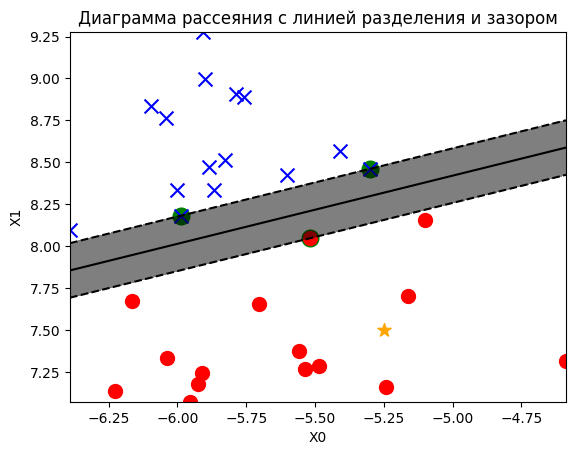

In [145]:
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)

При помощи соответствующего метода класса найдет значение функции гипотезы в этой точке:

In [146]:
svm_linear.decision_function(observation_new)

array([-5.03131797])

И конечно предсказание класса в ней же:

In [147]:
svm_linear.predict(observation_new)

array([0])

По результатам анализа видно, что построенная модель работает идеально. Но это только самый простой случай.

##### Линейно неразделимые данные с зазором

Для более сложного применения метода опорных векторов сгенерируем датасет совершенно другой формы:

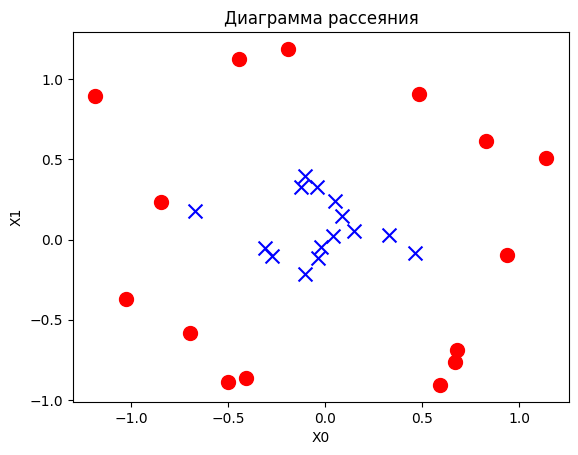

In [148]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()


Для этого набора данных воспользуемся методом опорных векторов в гауссовым ядром:

In [149]:
svm_rbf = SVC(kernel='rbf', C=100).fit(X, y)

Выведем данные об опорных векторах:

In [150]:
svm_rbf.n_support_
svm_rbf.support_
svm_rbf.support_vectors_

array([[ 0.9388294 , -0.09554628],
       [-0.84682371,  0.23287306],
       [-0.19166925,  1.18895776],
       [-0.69539045, -0.58523359],
       [ 0.68060508, -0.68615145],
       [ 0.48354792,  0.91063288],
       [-0.66975235,  0.17866445],
       [ 0.46427295, -0.08540628]])

И построим данную модель на графике:

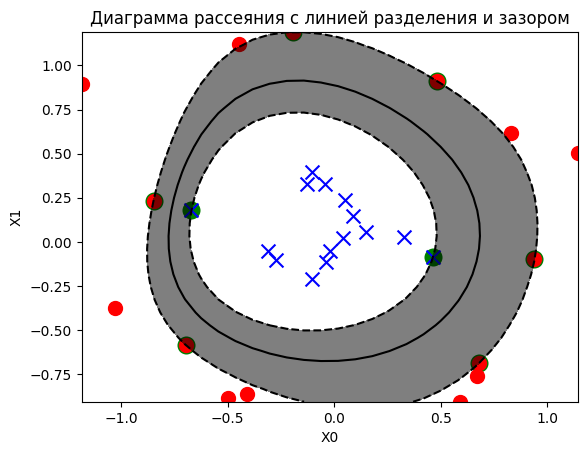

In [151]:
plot_decision_regions(X, y, svm_rbf)

На графике мы видим, как располагаются опорные вектора, граница принятия решения и полоса зазора:

Здесь ясно видно, что за счет применения другой функции ядра, по сути - другой метрики расстояния между точками, граница принятия решения изгибается определенным образом. Но опорные вектора, как всегда - это наиболее близкие к другому классу точки. Только теперь расстояние (точнее, мера близости рассчитывается по-другому).

Посчитаем метрики данной модели:

In [152]:
metrics.accuracy_score(y, y_pred)
metrics.confusion_matrix(y, y_pred)

array([[7, 8],
       [8, 7]])

Какой можно сделать вывод о качестве ее работы?

Модель работоспособна, но качество низкое из-за высокой сложности разделения классов (сильное перекрытие окружностей).

##### Данные без зазора

Как будет себя вести метод опорных векторов, если в данных между классами вообще нет никакого зазора? Давайте сгенерируем такой набор данных и посмотрим:

In [ ]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

На диаграмме мы видим, что классы как бы "перемешиваются", никакого зазора между ними нет. В таком случае, нам нужно применить метод опорных векторов с так называемым мягким зазором. Это достигается уменьшением параметра регуляризации (С):

In [ ]:
svm_poly = SVC(kernel='poly', degree=4, C=2).fit(X, y)

Построим данную модель на графике:

In [ ]:
plot_decision_regions(X, y, svm_poly)

Мы видим довольно широкую полосу зазора:
Но самое главное, что уменьшение регуляризации модели приводит к тому, что модель допускает некоторые погрешности в попадании точек в полосу зазора. За счет этого, модель все-таки формирует оптимальную разделяющую прямую.

Но при этом опорными векторами станут гораздо больше точек:

In [ ]:
svm_poly.n_support_

Можно сделать вывод, что чем меньше зазор между классами, тем менее эффективен метод опорных векторов.

Также, как и в предыдущих заданиях, выведем значение метрик для данной модели:


In [ ]:
metrics.accuracy_score(y, y_pred)
metrics.confusion_matrix(y, y_pred)


Можно сделать вывод, что данная модель, хоть и не идеальная, все же довольно точно справляется с классификацией.

### Контрольные вопросы

**1. Чем отличается класс SVC и LinearSVC в библиотеке sklearn при использовании метода опорных векторов без ядра?**  
- **SVC(kernel='linear')** использует более общий алгоритм, основанный на библиотеке libsvm, и поддерживает вывод опорных векторов (`support_vectors_`), но работает медленнее на больших данных.  
- **LinearSVC** реализован на основе liblinear, оптимизирован для линейного случая, работает быстрее на больших выборках, но **не предоставляет** информацию об опорных векторах. Также LinearSVC использует другую функцию потерь (hinge loss с регуляризацией) и имеет немного другие параметры (например, `penalty` и `loss`).

**2. Чем отличается метод опорных векторов с разными ядрами? Как выбор функции ядра влияет на форму границы принятия решения?**  
- **Линейное ядро (`kernel='linear'`)** – порождает прямую (в 2D) или гиперплоскость (в многомерном пространстве). Подходит для линейно разделимых данных.  
- **Полиномиальное ядро (`kernel='poly'`)** – создаёт границу в виде кривой (параболы, гиперболы и т.д.). Степень полинома управляет сложностью границы.  
- **RBF (гауссово) ядро (`kernel='rbf'`)** – порождает локальные, радиально-симметричные границы, может аппроксимировать любую сложную форму при достаточном количестве опорных векторов. Наиболее гибкое, но склонно к переобучению при малом `C`.  
- Выбор ядра определяет **геометрическую форму разделяющей поверхности**: линейная – прямая; полиномиальная – гладкая кривая; RBF – множество локальных «пузырей».

**3. Как метод опорных векторов работает в задачах множественной классификации?**  
SVM изначально решает задачу бинарной классификации. Для множественной классификации в sklearn используются две стратегии:  
- **One-vs-One (OvO)** – строится отдельный классификатор для каждой пары классов, итоговый класс определяется голосованием.  
- **One-vs-Rest (OvR)** – строится один классификатор для каждого класса против всех остальных, выбирается класс с максимальной уверенностью.  
В `SVC` по умолчанию используется **OvO** для `decision_function_shape='ovo'` (до версии 1.7), а для `decision_function_shape='ovr'` – OvR. `LinearSVC` использует OvR.

**4. Как метод опорных векторов может быть использован для решения задачи регрессии?**  
В библиотеке sklearn существует класс **`SVR` (Support Vector Regression)**. Идея: ищем функцию, которая отклоняется от реальных значений не более чем на заданную величину ε (эпсилон-трубка), при этом стремясь сделать функцию как можно более плоской. Точки, попадающие внутрь трубки, не влияют на модель (их ошибка не учитывается), а точки вне трубки дают вклад в функцию потерь. Гиперпараметр `C` управляет компромиссом между шириной трубки и допустимыми нарушениями.